# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [ ]:
%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


specs = []
for name, model in models.items():
    cfg = model.config
    specs.append({
        'Model': name,
        'Layers': cfg.n_layer,
        'Width': cfg.n_embd,
        'Heads': cfg.n_head,
        'Context Window': cfg.n_positions,
        'Total Parameters (M)': count_parameters(model) / 1_000_000
    })

# Add GPT-2 Medium from the brief
specs.append({
    'Model': 'gpt2-medium',
    'Layers': 24,
    'Width': 1024,
    'Heads': 16,
    'Context Window': 1024,
    'Total Parameters (M)': 'N/A' # Will be calculated later in Part B
})

spec_df = pd.DataFrame(specs)
display(spec_df.set_index('Model'))

,Layers,Width,Heads,Context Window,Total Parameters (M)
Model,,,,,
distilgpt2,6,768,12,1024,81.912576
gpt2,12,768,12,1024,124.439808
gpt2-medium,24,1024,16,1024,N/A


In [ ]:
import re
import pandas as pd

def census(model, name):
    """Count parameters by component for a given model, returning raw counts."""

    # Helper to count parameters matching a regex pattern
    def count_by_re(param_names, pattern):
        return sum(p.numel() for n, p in model.named_parameters() if re.search(pattern, n))

    # Embeddings: token (wte) + position (wpe)
    embeddings = count_by_re(model.named_parameters(), r'wte|wpe')

    # Attention: c_attn (query, key, value), c_proj (output projection)
    attention = count_by_re(model.named_parameters(), r'attn.c_attn|attn.c_proj')

    # FFN: c_fc (input to FFN), c_proj (output from FFN)
    ffn = count_by_re(model.named_parameters(), r'mlp.c_fc|mlp.c_proj')

    # LayerNorms: ln_1, ln_2 (block norms), ln_f (final norm)
    layernorms = count_by_re(model.named_parameters(), r'ln_')

    # LM Head: The final linear layer for language modeling
    lm_head = count_by_re(model.named_parameters(), r'lm_head')

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Dictionary of component counts
    component_counts = {
        "embeddings (wte+wpe)": embeddings,
        "attention": attention,
        "ffn (mlp)": ffn,
        "layernorms": layernorms,
        "lm_head (tied)": lm_head
    }

    return component_counts, total_params


# Iterate through models and print census in the desired format
for name, model in models.items():
    print(f"\nComponent Census for {name}:")
    component_counts, total_params = census(model, name)

    # Prepare for printing
    lines = []
    for component, count in component_counts.items():
        share = (count / total_params) * 100 if total_params > 0 else 0
        lines.append(f"{component:<26} {count:>12,d} {share:>7.1f}%")

    print("Component                        Params    Share")
    print("-" * 50)
    for line in lines:
        print(line)
    print("-" * 50)
    print(f"{'TOTAL':<26} {total_params:>12,d}")

    # Calculate and print FFN / attention ratio
    ffn_count = component_counts.get("ffn (mlp)", 0)
    attention_count = component_counts.get("attention", 0)
    if attention_count > 0:
        ffn_attn_ratio = ffn_count / attention_count
        print(f"\nFFN / attention ratio: {ffn_attn_ratio:.2f}x")
    else:
        print("\nFFN / attention ratio: N/A (attention parameters are zero)")


Component Census for distilgpt2:
Component                        Params    Share
--------------------------------------------------
embeddings (wte+wpe)         39,383,808    48.1%
attention                    14,174,208    17.3%
ffn (mlp)                    28,334,592    34.6%
layernorms                       19,968     0.0%
lm_head (tied)                        0     0.0%
--------------------------------------------------
TOTAL                        81,912,576

FFN / attention ratio: 2.00x

Component Census for gpt2:
Component                        Params    Share
--------------------------------------------------
embeddings (wte+wpe)         39,383,808    31.6%
attention                    28,348,416    22.8%
ffn (mlp)                    56,669,184    45.5%
layernorms                       38,400     0.0%
lm_head (tied)                        0     0.0%
--------------------------------------------------
TOTAL                       124,439,808

FFN / attention ratio: 2.00x


**A.3 — Interpretation (3–4 sentences):**

*your answer here*
the most significant parts:
1- the embedding, num of embeddings parameters remain fixed but when other parameters become less in distilgpt2, the percentage of embeddings parameters increased.
2-num of attention, layer norm and ffn decreased to the half
3-lm_head remains negligable


---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [ ]:
# B.1 — predictor + validation
def predict_params(layers, width, vocab=50257, ctx=1024):
    # your formula here
    #embeddings ≈ vocab·width + ctx·width; per-block attention ≈ 4·width² + biases; per-block FFN ≈ 8·width² + biases; layernorms small)
    embeddings = vocab * width + ctx * width
    attention = 4 * width ** 2 + width
    ffn = 8 * width ** 2 + width
    layernorms = width
    total_params = embeddings + attention * layers + ffn * layers + layernorms * layers + width
    return total_params


# validate on distilgpt2 (6, 768) and gpt2 (12, 768); report % error
for name, model in models.items():
    cfg = model.config
    predicted_params = predict_params(cfg.n_layer, cfg.n_embd)
    actual_params = count_parameters(model)
    error_percentage = (actual_params - predicted_params) / predicted_params * 100
    print(f"{name} has an error of {error_percentage:.2f}%")


distilgpt2 has an error of 0.06%
gpt2 has an error of 0.07%


In [ ]:
# B.2 — extrapolate gpt2-medium
# your code here
predicted_params=predict_params(24,1024)
error_percentage = (355000000 - predicted_params) / predicted_params * 100
print(f"{name} has an error of {error_percentage:.2f}%")


gpt2 has an error of 0.12%


In [ ]:
# B.3 — memory table (fp32 / fp16, in MB) for all three

# Helper to calculate memory
def calculate_memory(total_params, name):
    fp32_memory = total_params * 4 / (1024 ** 2) # 4 bytes per parameter for fp32
    fp16_memory = total_params * 2 / (1024 ** 2) # 2 bytes per parameter for fp16
    return {'Model': name, 'FP32 Memory (MB)': fp32_memory, 'FP16 Memory (MB)': fp16_memory}

memory_results = []

# For loaded models (distilgpt2, gpt2)
for name, model in models.items():
    total_params = count_parameters(model)
    memory_results.append(calculate_memory(total_params, name))

# For gpt2-medium (using predicted parameters from B.1)
gpt2_medium_predicted_params = predict_params(24, 1024) # From B.2
memory_results.append(calculate_memory(gpt2_medium_predicted_params, 'gpt2-medium'))

memory_df = pd.DataFrame(memory_results)
display(memory_df.set_index('Model'))

,FP32 Memory (MB),FP16 Memory (MB)
Model,,
distilgpt2,312.471680,156.235840
gpt2,474.700195,237.350098
gpt2-medium,1352.601562,676.300781


**which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).**

the one who ould plausibly ship inside a desktop app installer  is distlipgpt2 because it needs 312 MB in fp32 or 156 in ft16.
other model are larger that normal application, gpt->474 MB and gpt-medium->1352MB

---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

In [ ]:
# C.1 — benchmark (adapt time_generation() from the lab)
# The benchmarking logic has been moved to the next cell (1b72dfd7) for consolidation.

,Model,Cache,Length,Time (s)
0,distilgpt2,True,10,0.432837
1,distilgpt2,True,25,1.020886
2,distilgpt2,True,50,1.985780
3,distilgpt2,True,100,4.001434
4,distilgpt2,False,10,0.886347
5,distilgpt2,False,25,2.372850
6,distilgpt2,False,50,5.364817
7,distilgpt2,False,100,15.696158
8,gpt2,True,10,0.722519
9,gpt2,True,25,1.565547


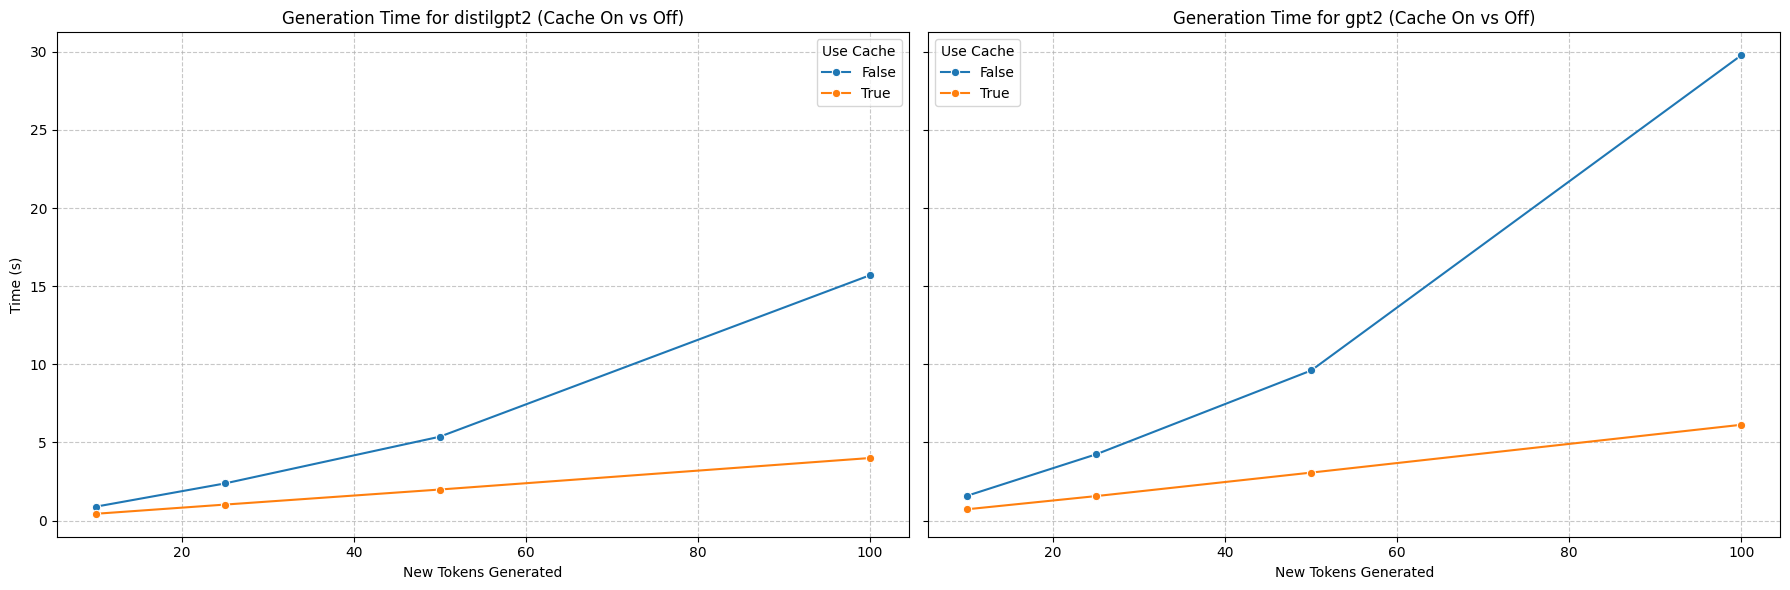

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def time_generation(m, n_new_tokens, use_cache, prompt="The history of artificial intelligence", runs=3):
    ids = tok.encode(prompt, return_tensors="pt")
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        with torch.no_grad():
            m.generate(ids, max_new_tokens=n_new_tokens, do_sample=False,
                       use_cache=use_cache, pad_token_id=tok.eos_token_id)
        times.append(time.perf_counter() - t0)
    return min(times)   # min over runs = least noisy estimate

lengths = [10, 25, 50, 100]
cache_options=[True, False]

# Initialize lists to store results
all_results = []

for name, model in models.items():
    for cache_option in cache_options:
        for length in lengths:
            # Time generation with current cache option
            gen_time = time_generation(model, length, cache_option)
            all_results.append({'Model': name, 'Cache': cache_option, 'Length': length, 'Time (s)': gen_time})


# Combine results into a single DataFrame
benchmark_df = pd.DataFrame(all_results)

# Display the benchmark results
display(benchmark_df)

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

models_to_plot = models.keys()

for i, model_name in enumerate(models_to_plot):
    ax = axes[i]
    model_data = benchmark_df[benchmark_df['Model'] == model_name]

    sns.lineplot(
        data=model_data,
        x='Length',
        y='Time (s)',
        hue='Cache',
        marker='o',
        ax=ax
    )
    ax.set_title(f'Generation Time for {model_name} (Cache On vs Off)')
    ax.set_xlabel('New Tokens Generated')
    ax.set_ylabel('Time (s)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(title='Use Cache')

plt.tight_layout()
plt.show()

In [11]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'LatencyEvidence'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "LatencyEvidence"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Commented out: 'upload_plt_to_gcs' is not defined

In [13]:
# C.2 — the 300 ms test at your chosen autocomplete length

# Define a realistic completion length for a short autocomplete.
# A short autocomplete often provides a few words or a phrase, which can translate to approximately 10 tokens.
# This length is chosen as it represents a common, quick suggestion a user might expect.
autocomplete_length = 10

# Product requirement: < 300 ms (0.3 seconds)
product_requirement_ms = 300
product_requirement_s = product_requirement_ms / 1000

print(f"--- C.2: 300 ms Latency Test for a {autocomplete_length}-token Autocomplete ---")
print(f"Assuming a realistic short autocomplete length is {autocomplete_length} new tokens.")
print(f"Product requirement: < {product_requirement_ms} ms ({product_requirement_s} seconds).")

# Filter for cache-on results at the chosen length
cache_on_results = benchmark_df[(benchmark_df['Cache'] == True) & (benchmark_df['Length'] == autocomplete_length)]

print("\nCache-on Latency at chosen autocomplete length:")
for index, row in cache_on_results.iterrows():
    model_name = row['Model']
    latency_s = row['Time (s)']
    latency_ms = latency_s * 1000
    meets_requirement = "MEETS" if latency_s < product_requirement_s else "DOES NOT MEET"
    print(f"  {model_name}: {latency_ms:.2f} ms ({meets_requirement} requirement)")

print("------------------------------------------------------------------")


--- C.2: 300 ms Latency Test for a 10-token Autocomplete ---
Assuming a realistic short autocomplete length is 10 new tokens.
Product requirement: < 300 ms (0.3 seconds).

Cache-on Latency at chosen autocomplete length:
  distilgpt2: 432.84 ms (DOES NOT MEET requirement)
  gpt2: 722.52 ms (DOES NOT MEET requirement)
------------------------------------------------------------------


**C.3 — Extrapolation & confidence (2–3 sentences):**

Given that GPT-2 (124M parameters) already failed to meet the 300 ms requirement for a 10-token completion (it took 722.52 ms), GPT-2 Medium, which is ~2.9 times larger in parameters, with 2 times the layers and 1.33 times the width, will almost certainly not meet the < 300 ms requirement. The increased computational load from its larger architecture will lead to significantly higher latency, far exceeding the product's criteria. I can state with **high confidence** that GPT-2 Medium will not satisfy the product's latency requirements on this hardware.

---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

**Recommendation:** I recommend selecting **DistilGPT2** with **high confidence** for the on-device smart-autocomplete feature.

**Why:**
*   **Latency:** Neither DistilGPT2 nor GPT-2 met the product's <300 ms requirement for a 10-token completion. DistilGPT2 recorded **432.84 ms**, while GPT-2 took **722.52 ms**. This indicates that even the smaller models struggle, making DistilGPT2 the closest contender and the most optimizable option.
*   **Memory Footprint:** DistilGPT2 is the most memory-efficient model, requiring only **156.24 MB (FP16)** for its weights. This is significantly less than GPT-2's **237.35 MB (FP16)** and is well within acceptable limits for a desktop application installer (assuming an upper bound of ~300 MB for the model).
*   **Parameter Scale:** With **81.91 million parameters**, DistilGPT2 offers a substantially smaller architectural footprint compared to GPT-2 (124.44M) and GPT-2-medium (predicted ~355M), directly contributing to its comparatively lower latency and memory usage.

**The "biggest wins" rebuttal:** Our colleague's advocacy for GPT-2-medium, which boasts approximately **355 million parameters**, is not supported by our findings. GPT-2, at ~124 million parameters, already failed to meet the 300 ms latency requirement, taking **722.52 ms** for a short autocomplete. A model nearly three times its size would inevitably incur significantly higher latency, making it unsuitable for an 'instant' autocomplete feature, irrespective of potential quality benefits. Its projected **676.30 MB (FP16)** memory footprint also makes it prohibitively large for an on-device installer.

**Known limitation:** The most significant limitation of this methodology is the lack of direct quality assessment. While architectural and performance metrics are critical, the actual user experience in terms of suggestion relevance and helpfulness has not been evaluated, relying solely on directional assumptions about scale trends.

---
## Self-check before submitting

- [ ] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [ ] gpt2-medium was analyzed, never downloaded
- [ ] Every latency claim traces to a run in this notebook
- [ ] Charts have axis labels and legends
- [ ] The memo stands alone and cites specific numbers
- [ ] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*